In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from typing_extensions import Literal 
from langchain.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph , START, END, MessagesState
from langgraph.types import Command
from langchain_core.messages import BaseMessage, HumanMessage
from langchain.agents import create_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

In [ ]:
# llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [16]:
llm.invoke("Hi How are you?")

AIMessage(content="Hey! I'm doing great, thanks for asking! 😊 How about you?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 31, 'total_tokens': 48, 'completion_time': 0.055610067, 'completion_tokens_details': None, 'prompt_time': 0.009811904, 'prompt_tokens_details': None, 'queue_time': 0.334724981, 'total_time': 0.065421971}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_241bc7119c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3a83-4e24-7d93-b153-53bb6ed8d340-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens': 17, 'total_tokens': 48})

In [34]:
def add_number(state):
    result=state["number1"]+state["number2"]
    print(f'Additional Result: {result}')
    return Command(goto='multiply', update={'sum': result})

In [35]:
state={
    "number1": 5,
    "number2": 10
}

In [36]:
add_number(state)

Additional Result: 15


Command(update={'sum': 15}, goto='multiply')

In [31]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [32]:
@tool
def transfer_to_additional_expert():
    """Ask addition agent for help"""
    return

In [39]:
def additional_expert(state: MessagesState) -> Command[Literal['multiplication_expert', '__end__']]:
    system_prompt=(
        "You are an addition expert, you can ask the multiplication expert for help with multiplication problems."
        "Always do your portion of calculation before the handoff."
    )
    messages=[{'role':'system', 'content':system_prompt}] + state['messages']
    ai_msg=llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls)>0:
        tool_call_id=ai_msg.tool_calls[-1]['id']
        tool_msg={
            'role': 'tool',
            'content':'Sucessfully transferred',
            "tool_call_id": tool_call_id
        }
        return Command(
            goto='multiplication_expert', 
            update={'messages': [ai_msg, tool_msg]}
        )
    return Command(goto='__end__', update={'messages': [ai_msg]})

In [40]:
def multiplication_expert(state: MessagesState) -> Command[Literal['additional_expert', '__end__']]:
    system_prompt=(
        "You are a multiplication expert, you can ask the addition expert for help with addition problems."
        "Always do your portion of calculation before the handoff."
    )
    messages=[{'role':'system', 'content':system_prompt}] + state['messages']
    ai_msg=llm.bind_tools([transfer_to_additional_expert]).invoke(messages)
    if len(ai_msg.tool_calls)>0:
        tool_call_id=ai_msg.tool_calls[-1]['id']
        tool_msg={
            'role': 'tool',
            'content':'Sucessfully transferred',
            "tool_call_id": tool_call_id,
        }
        return Command(
            goto='additional_expert', 
            update={'messages': [ai_msg, tool_msg]}
        )
    return Command(goto='__end__', update={'messages': [ai_msg]})

In [41]:
graph=StateGraph(MessagesState)

In [42]:
graph.add_node("additional_expert", additional_expert)
graph.add_node("multiplication_expert", multiplication_expert)

In [43]:
graph.add_edge(START, "additional_expert")

In [44]:
app=graph.compile()

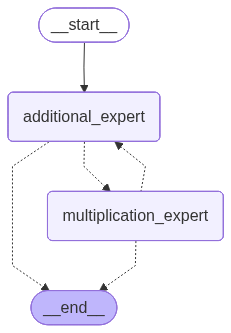

In [30]:
app

In [45]:
app.invoke({'messages': [('user', "what's (3+4)*5? Provide me the output.")]})

{'messages': [HumanMessage(content="what's (3+4)*5? Provide me the output.", additional_kwargs={}, response_metadata={}, id='0f342872-93dd-4332-b5ec-14e5f01a59b5'),
  AIMessage(content="I can help you with this calculation! Let me break it down:\n\nFirst, I'll handle the addition part: 3 + 4 = 7\n\nNow I need to multiply this result by 5. Let me get help from the multiplication expert for the multiplication part.", additional_kwargs={'tool_calls': [{'id': 'functions.transfer_to_multiplication_expert:0', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 105, 'total_tokens': 176, 'completion_time': 0.29410001, 'completion_tokens_details': None, 'prompt_time': 0.027541947, 'prompt_tokens_details': None, 'queue_time': 0.282252672, 'total_time': 0.321641957}, 'model_name': 'moonshotai/kimi-k2-instruct-0905', 'system_fingerprint': 'fp_05df423bab', 'service_tier': 'o

In [56]:
@tool
def transfer_to_travel_advisor():
    """Ask travel advisor for help"""
    return
@tool
def transfer_to_hotel_advisor():
    """Ask hotel advisor for help"""
    return

In [57]:
def travel_advisor(state: MessagesState) -> Command[Literal['hotel_advisor', '__end__']]:
    system_prompt=(
        "You are a general travel expert tht can recomend travel destinations(e.g. countries, cities, tourist attractions, etc.)."
        "If you neeed hotel recomendations, ask the hotel advisor for help."
        "Always provide travel advice before the handoff."
    )
    messages=[{'role':'system', 'content':system_prompt}] + state['messages']

    try:
        ai_msg=llm.bind_tools([transfer_to_hotel_advisor]).invoke(messages)
    except Exception:
        # Fallback when provider tool-calling fails: return a direct answer instead of crashing.
        ai_msg=llm.invoke(messages)
        return Command(goto='__end__', update={'messages': [ai_msg]})

    if len(ai_msg.tool_calls)>0:
        tool_call_id=ai_msg.tool_calls[-1]['id']
        tool_msg={
            'role': 'tool',
            'content':'Sucessfully transferred',
            "tool_call_id": tool_call_id
        }
        return Command(
            goto='hotel_advisor',
            update={'messages': [ai_msg, tool_msg]}
        )
    return Command(goto='__end__', update={'messages': [ai_msg]})

In [58]:
def hotel_advisor(state: MessagesState) -> Command[Literal['travel_advisor', '__end__']]:
    system_prompt=(
        "You are a hotel expert tht can recomend hotels based on user's needs and preferences."
        "If you neeed travel recomendations, ask the travel advisor for help."
        "Always provide hotel advice before the handoff."
    )
    messages=[{'role':'system', 'content':system_prompt}] + state['messages']

    try:
        ai_msg=llm.bind_tools([transfer_to_travel_advisor]).invoke(messages)
    except Exception:
        # Fallback when provider tool-calling fails: return a direct answer instead of crashing.
        ai_msg=llm.invoke(messages)
        return Command(goto='__end__', update={'messages': [ai_msg]})

    if len(ai_msg.tool_calls)>0:
        tool_call_id=ai_msg.tool_calls[-1]['id']
        tool_msg={
            'role': 'tool',
            'content':'Sucessfully transferred',
            "tool_call_id": tool_call_id
        }
        return Command(
            goto='travel_advisor',
            update={'messages': [ai_msg, tool_msg]}
        )
    return Command(goto='__end__', update={'messages': [ai_msg]})

In [59]:
graph1=StateGraph(MessagesState)
graph1.add_node("travel_advisor", travel_advisor)
graph1.add_node("hotel_advisor", hotel_advisor)

In [60]:
graph1.add_edge(START, "travel_advisor")

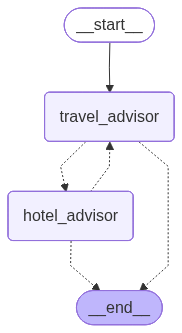

In [61]:
app1=graph1.compile()
app1

In [62]:
response=app1.invoke({'messages': [('user', "I want a family trip to Dubai with kids activities and transport advice, then ask hotel advisor for family-friendly hotels with breakfast and pool.")]})

In [66]:
response

{'messages': [HumanMessage(content='I want a family trip to Dubai with kids activities and transport advice, then ask hotel advisor for family-friendly hotels with breakfast and pool.', additional_kwargs={}, response_metadata={}, id='b016c085-7f48-4fc9-8beb-32c6885192ff'),
  AIMessage(content="Dubai is a fantastic destination for a family trip, with plenty of kid-friendly activities and attractions. Some top recommendations include the Dubai Mall, which features an indoor ice skating rink, a virtual reality park, and a massive aquarium. You can also visit the Global Village, a cultural and entertainment park with rides, shows, and attractions from around the world. For outdoor fun, head to the Jumeirah Beach or the Dubai Miracle Garden, a stunning floral wonderland.\n\nFor transportation, consider using the Dubai Metro, a convenient and efficient way to get around the city. You can also use taxis or ride-hailing services, which are widely available. If you prefer to drive, many car ren

In [65]:
app1.invoke({'messages': [('user', "I want to travel to India, can you give me some advice and travel and hotel recommendations?")]})

{'messages': [HumanMessage(content='I want to travel to India, can you give me some advice and travel and hotel recommendations?', additional_kwargs={}, response_metadata={}, id='8423c930-bf12-4441-aa32-19784cc32d78'),
  AIMessage(content="India is a vast and diverse country, offering a wide range of experiences for travelers. Before I can provide you with hotel recommendations, let me offer some general travel advice. \n\nIndia is a country with a rich history, vibrant culture, and Vast natural beauty. From the snow-capped Himalayas to the sun-kissed beaches of the south, India has something to offer for every kind of traveler. Some popular destinations in India include the Taj Mahal in Agra, the Golden Temple in Amritsar, the backwaters of Kerala, and the vibrant cities of Mumbai and Delhi.\n\nWhen traveling to India, it's essential to be prepared for the crowds, noise, and chaos that can be overwhelming, especially for first-time visitors. It's also crucial to respect local customs 

In [74]:
def pretty_print_messages(chunk):
    messages = chunk.get("messages", []) if isinstance(chunk, dict) else []
    if not isinstance(messages, list):
        messages = [messages]

    if not messages:
        print(chunk)
        return

    for msg in messages:
        if hasattr(msg, "pretty_print"):
            msg.pretty_print()
        else:
            print(msg)

In [73]:
for chunk in app1.stream(
    {
        "messages": [
            (
                "user",
                "I am planning a trip to the California in the USA from Mumbai. What are the best flight routes and can you guide me on travel options and suggest the best hotel?",
            )
        ]
    },
):
    print("****chunk****")
    pretty_print_messages(chunk)

****chunk****
{'travel_advisor': {'messages': [AIMessage(content='For traveling from Mumbai to California, the best flight routes usually involve a layover, with popular options including flights with one stop in cities like London, Dubai, or Hong Kong. Some of the major airlines that operate this route are Air India, Emirates, British Airways, and American Airlines. \n\nAs for travel options, California has a lot to offer, from the scenic Pacific Coast Highway to the vibrant cities of Los Angeles and San Francisco. Some must-visit attractions include Yosemite National Park, the Golden Gate Bridge, and Disneyland. \n\nFor the best hotel recommendations, I would suggest asking the hotel advisor for help. \n\n', additional_kwargs={'tool_calls': [{'id': 'nmwatz5k9', 'function': {'arguments': '{}', 'name': 'transfer_to_hotel_advisor'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 137, 'prompt_tokens': 291, 'total_tokens': 428, 'completion_time': 0.46902724